In [63]:
# Real Estate Pricing Analysis – Exploratory Data Analysis

##This project analyzes real estate pricing data to understand the key factors influencing house prices using exploratory data analysis andfeature engineering techniques.


In [64]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [65]:
### Task 1: Loading the Data
###The dataset is loaded into a Pandas DataFrame to enable easy data manipulation and analysis.


In [66]:
import pandas as pd

df = pd.read_csv("housing_data (1).csv")
df.head()


,Unnamed: 0,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,0,SC60,RL,65,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,No,No,No,0,Feb,2008,WD,Normal,208500
1,1,SC20,RL,80,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,No,No,No,0,May,2007,WD,Normal,181500
2,2,SC60,RL,68,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,No,No,No,0,Sep,2008,WD,Normal,223500
3,3,SC70,RL,60,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,No,No,No,0,Feb,2006,WD,Abnorml,140000
4,4,SC60,RL,84,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,No,No,No,0,Dec,2008,WD,Normal,250000


In [67]:
## Task 2: Cleaning the Data

##This step improves data quality by removing duplicate records, handling missing values, and eliminating unnecessary columns that do not contribute to the analysis.


In [68]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Remove unnecessary index column if present
df.drop(columns=["Unnamed: 0"], errors="ignore", inplace=True)

# Handle missing values in numeric columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Verify cleaning
df.isnull().sum()


,0
MSSubClass,0
MSZoning,0
LotFrontage,0
LotArea,0
Street,0
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


In [69]:
## Task 3: Univariate Analysis
###Univariate analysis is used to examine individual variables to understand their distribution and characteristics.Here, we analyze the distribution of house prices.


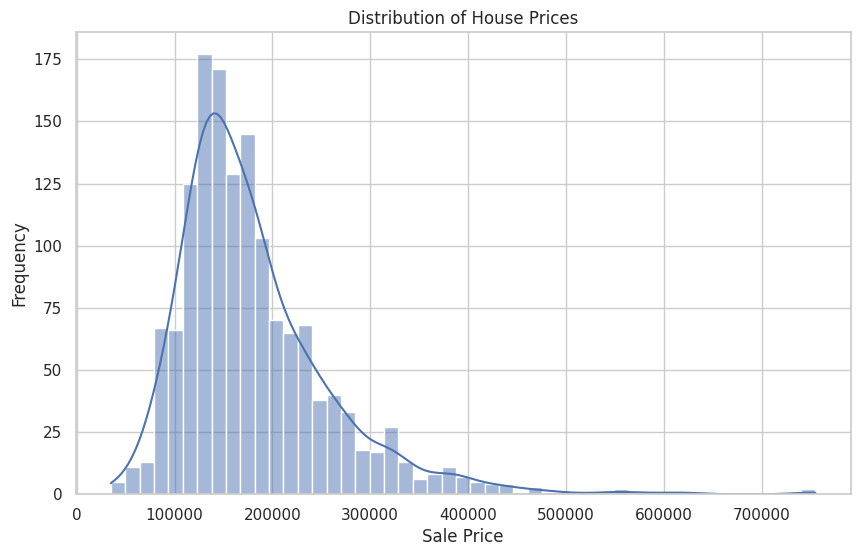

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.histplot(df["SalePrice"], kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")
plt.show()


In [71]:
## Task 4: Multivariate Analysis
##Multivariate analysis examines relationships between multiple variables. In this step, a correlation matrix is used to understand how different features are related to house prices.


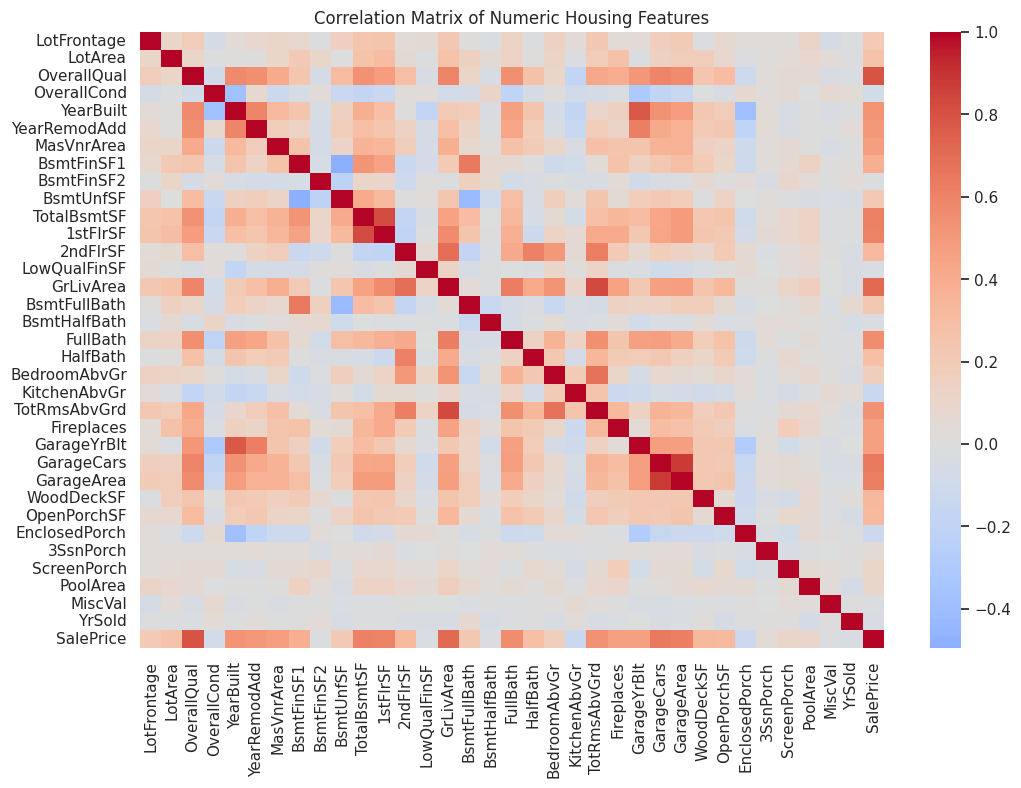

In [72]:
plt.figure(figsize=(12,8))

# Select only numeric columns
numeric_df = df.select_dtypes(include=["int64", "float64"])

# Compute correlation
corr_matrix = numeric_df.corr()

# Plot heatmap
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numeric Housing Features")
plt.show()


In [73]:
## Task 5: Feature Engineering

##Feature engineering involves creating new variables that capture important information not explicitly present in the dataset. In this step, new features are created to better explain house pricing.

In [74]:
# Feature 1: Price per square foot
df["Price_per_SqFt"] = df["SalePrice"] / df["GrLivArea"]

# Feature 2: House age at time of sale
df["House_Age"] = df["YrSold"] - df["YearBuilt"]

# Verify new features
df[["SalePrice", "GrLivArea", "Price_per_SqFt", "House_Age"]].head()


,SalePrice,GrLivArea,Price_per_SqFt,House_Age
0,208500,1710,121.929825,5
1,181500,1262,143.819334,31
2,223500,1786,125.139978,7
3,140000,1717,81.537566,91
4,250000,2198,113.739763,8


In [75]:
## Task 6: Feature Engineering and Size Impact
##This step analyzes how property size and related features such as living area and number of bedrooms collectively influence house prices.


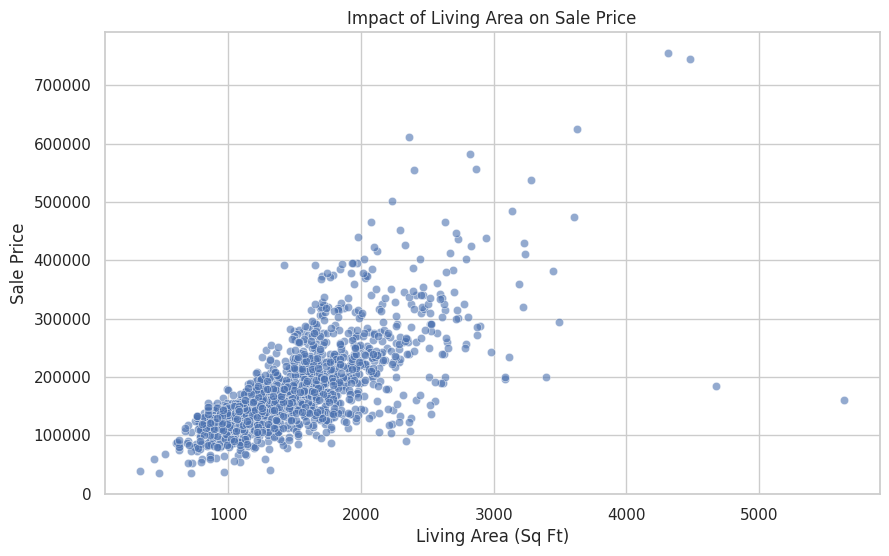

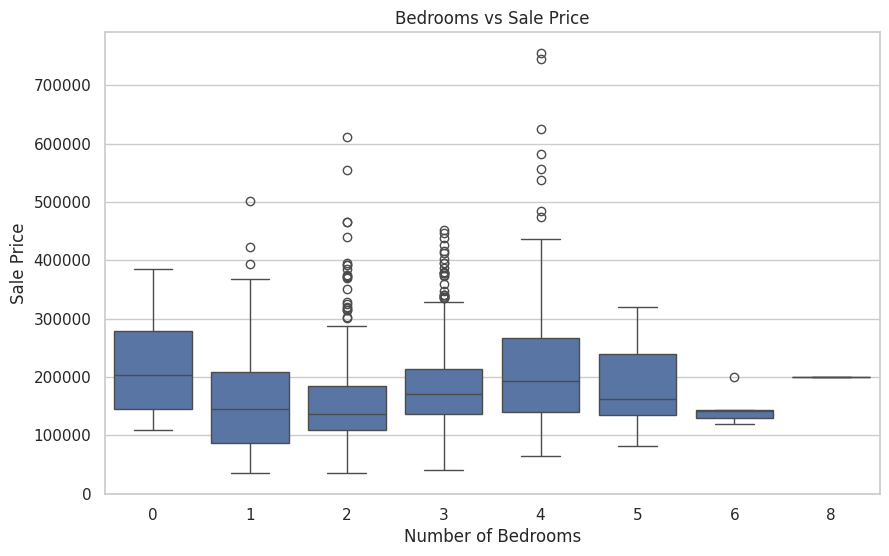

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

# Living Area vs Sale Price
plt.figure(figsize=(10,6))
sns.scatterplot(x="GrLivArea", y="SalePrice", data=df, alpha=0.6)
plt.title("Impact of Living Area on Sale Price")
plt.xlabel("Living Area (Sq Ft)")
plt.ylabel("Sale Price")
plt.show()

# Bedrooms vs Sale Price
plt.figure(figsize=(10,6))
sns.boxplot(x="BedroomAbvGr", y="SalePrice", data=df)
plt.title("Bedrooms vs Sale Price")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Sale Price")
plt.show()


In [77]:
## Task 7: Market Trends and Historical Pricing

##This step analyzes historical trends in house prices over time to understand how the real estate market has evolved across years.


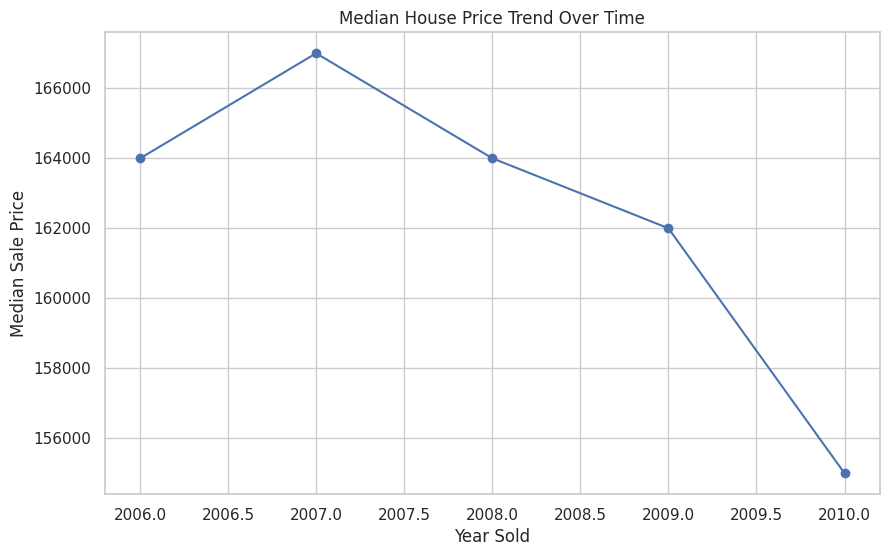

In [78]:
import matplotlib.pyplot as plt

# Median sale price trend over time
plt.figure(figsize=(10,6))
price_trend = df.groupby("YrSold")["SalePrice"].median()

plt.plot(price_trend.index, price_trend.values, marker="o")
plt.title("Median House Price Trend Over Time")
plt.xlabel("Year Sold")
plt.ylabel("Median Sale Price")
plt.show()


In [79]:
## Task 8: Customer Preferences and Amenities

##This step analyzes how specific amenities influence house prices. Amenities such as garage capacity are used as indicators of customerpreferences and their perceived value in the real estate market.


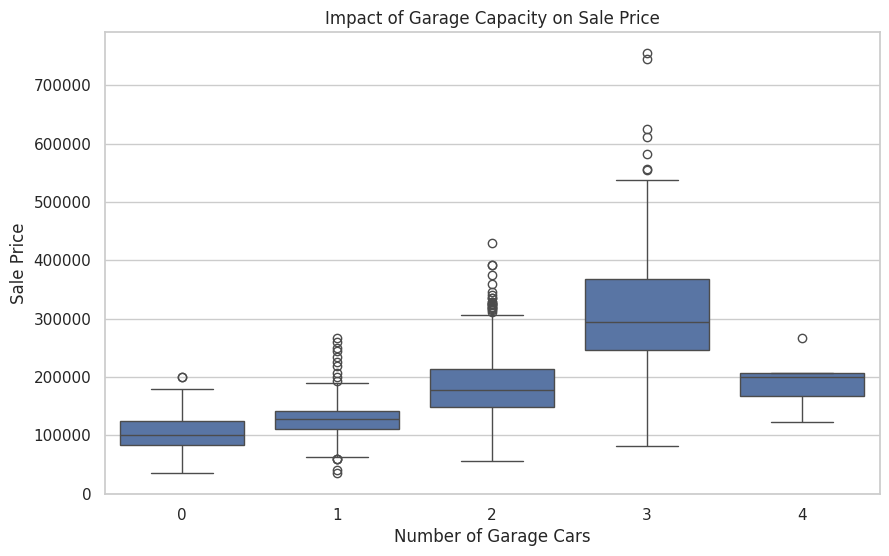

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.boxplot(x="GarageCars", y="SalePrice", data=df)
plt.title("Impact of Garage Capacity on Sale Price")
plt.xlabel("Number of Garage Cars")
plt.ylabel("Sale Price")
plt.show()


In [81]:
## Final Conclusion

### Key Findings:- #House prices are strongly influenced by living area and overall quality
#Larger homes generally command higher prices
#Amenities such as garage capacity significantly increase property value
#Feature engineering improves interpretability
#Market trends reveal changes in pricing behavior
